In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

df=pd.read_csv(r"StudentsPerformance.csv")

print("First rows of the dataset:")
print(df.head())



First rows of the dataset:
   gender race/ethnicity parental level of education         lunch  \
0  female        group B           bachelor's degree      standard   
1  female        group C                some college      standard   
2  female        group B             master's degree      standard   
3    male        group A          associate's degree  free/reduced   
4    male        group C                some college      standard   

  test preparation course  math score  reading score  writing score  
0                    none          72             72             74  
1               completed          69             90             88  
2                    none          90             95             93  
3                    none          47             57             44  
4                    none          76             78             75  


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [ ]:
print("\nDataset shape:")
print(df.shape)


Dataset shape:
(1000, 8)


In [ ]:
data=df["math score"].dropna()
print("\nNumber of math score values:",len(data))



Number of math score values: 1000


In [ ]:
Q1=data.quantile(0.25)
Q2=data.quantile(0.50)
Q3=data.quantile(0.75)
IQR=Q3-Q1

lower_limit=Q1-1.5*IQR
upper_limit=Q3+1.5*IQR
print("\nIQR METHOD")
print("Q1:",Q1)
print("Q2:",Q2)
print("Q3:",Q3)
print("IQR:",IQR)
print("Lower limit:",lower_limit)
print("Upper limit:",upper_limit)

iqr_outliers=df[(df["math score"]<lower_limit) | (df["math score"]>upper_limit)]
print("\nNumber of outliers:",len(iqr_outliers))


IQR METHOD
Q1: 57.0
Q2: 66.0
Q3: 77.0
IQR: 20.0
Lower limit: 27.0
Upper limit: 107.0

Number of outliers: 8


In [ ]:
mean=data.mean()
std_dev=data.std()
df["Z_score"]=(data-mean)/std_dev
z_score_outliers=df[df["Z_score"].abs()>3]
print("\nZ-SCORE METHOD")
print("Mean:",mean)
print("Standard deviation:",std_dev)
print("\nNumber of outliers:",len(z_score_outliers))



Z-SCORE METHOD
Mean: 66.089
Standard deviation: 15.163080096009468

Number of outliers: 4


In [ ]:
print("\nIQR OUTLIERS:")
if len(iqr_outliers)>0:
  print(iqr_outliers[["math score"]])
else:
  print("No IQR outliers found")

print("\nZ-SCORE OUTLIERS:")
if len(z_score_outliers)>0:
  print(z_score_outliers[["math score","Z_score"]])
else :
  print("No Z-score outliers found")


IQR OUTLIERS:
     math score
17           18
59            0
145          22
338          24
466          26
787          19
842          23
980           8

Z-SCORE OUTLIERS:
     math score   Z_score
17           18 -3.171453
59            0 -4.358547
787          19 -3.105504
980           8 -3.830950


In [ ]:
df["math_score_treated"]=df["math score"].clip(lower=lower_limit,upper=upper_limit)
print("Treatment method:Capping using IQR limits")

print("\nBEFORE TREATMENT")
print(df["math score"].describe())

print("\nAFTER TREATMENT")
print(df["math_score_treated"].describe())

Treatment method:Capping using IQR limits

BEFORE TREATMENT
count    1000.00000
mean       66.08900
std        15.16308
min         0.00000
25%        57.00000
50%        66.00000
75%        77.00000
max       100.00000
Name: math score, dtype: float64

AFTER TREATMENT
count    1000.000000
mean       66.165000
std        14.922414
min        27.000000
25%        57.000000
50%        66.000000
75%        77.000000
max       100.000000
Name: math_score_treated, dtype: float64


In [ ]:
comparison=df[["math score","math_score_treated"]]
print(comparison.head(20))

    math score  math_score_treated
0           72                  72
1           69                  69
2           90                  90
3           47                  47
4           76                  76
5           71                  71
6           88                  88
7           40                  40
8           64                  64
9           38                  38
10          58                  58
11          40                  40
12          65                  65
13          78                  78
14          50                  50
15          69                  69
16          88                  88
17          18                  27
18          46                  46
19          54                  54


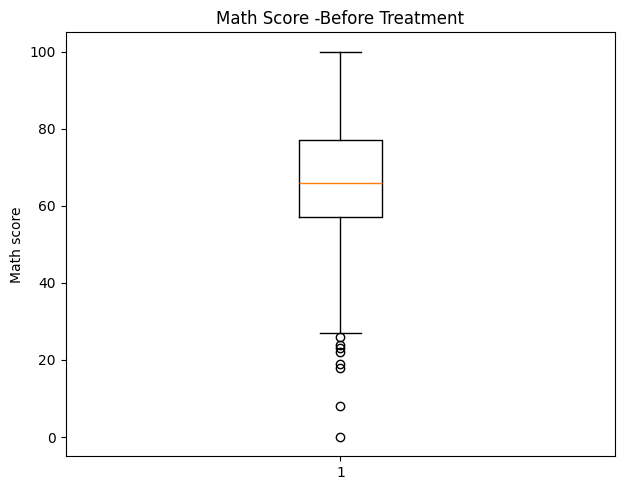

In [ ]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.boxplot(df["math score"].dropna())
plt.title("Math Score -Before Treatment")
plt.ylabel("Math score")
plt.tight_layout()
plt.show()

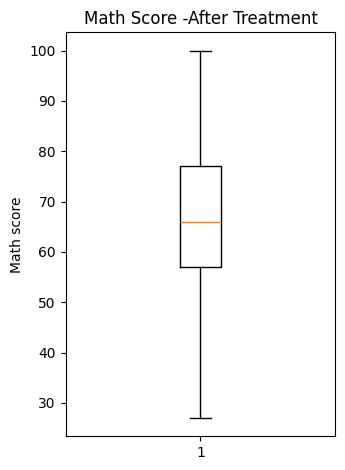

In [ ]:
plt.subplot(1,2,2)
plt.boxplot(df["math_score_treated"].dropna())
plt.title("Math Score -After Treatment")
plt.ylabel("Math score")
plt.tight_layout()
plt.show()